# Retail Sales Forecasting — 01 Exploratory Data Analysis

A **time-series** project that forecasts **daily sales revenue** for a UK online retailer (UCI Online Retail). We explore the series' trend, seasonality, and autocorrelation — the structure the forecasting models in notebook 03 will exploit.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

df=utils.load_data()
print('rows:',len(df),'| from',df.date.min(),'to',df.date.max())
df.head()

rows: 305 | from 2010-12-01 00:00:00 to 2011-12-09 00:00:00


,date,y
0,2010-12-01,58960.79
1,2010-12-02,47748.38
2,2010-12-03,46943.71
3,2010-12-05,31774.95
4,2010-12-06,54830.46


## 1. The series over time

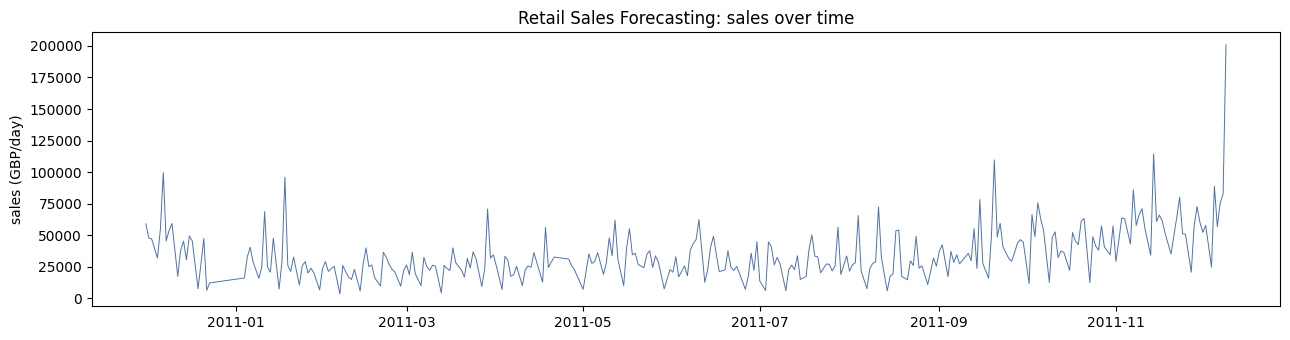

In [2]:
fig,ax=plt.subplots(figsize=(13,3.5))
ax.plot(df['date'],df['y'],lw=0.7,color='#4c72b0')
ax.set_title('Retail Sales Forecasting: sales over time'); ax.set_ylabel('sales (GBP/day)'); plt.tight_layout(); plt.show()

## 2. Distribution & summary

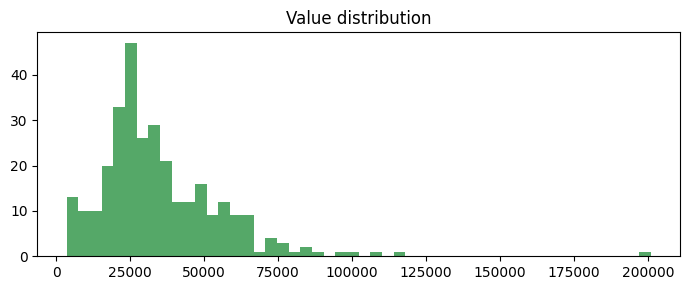

count       305.00
mean      34972.74
std       21116.96
min        3457.11
25%       22353.27
50%       29651.46
75%       45389.98
max      200920.60


In [3]:
fig,ax=plt.subplots(figsize=(7,3))
ax.hist(df['y'],bins=50,color='#55a868'); ax.set_title('Value distribution'); plt.tight_layout(); plt.show()
print(df['y'].describe().round(2).to_string())

## 3. Trend (rolling mean)

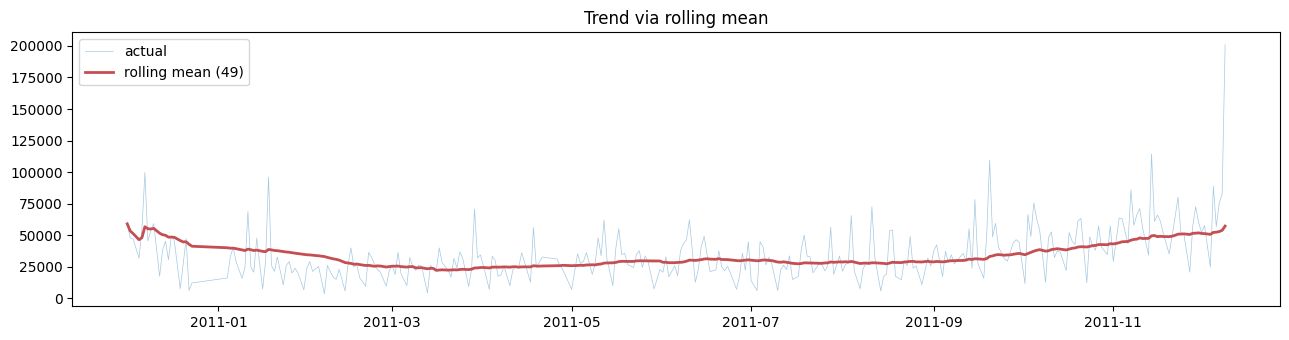

In [4]:
w=utils.SEASONAL_PERIOD* (7 if utils.FREQ=='D' else 7)
fig,ax=plt.subplots(figsize=(13,3.5))
ax.plot(df['date'],df['y'],lw=0.5,alpha=0.4,label='actual')
ax.plot(df['date'],df['y'].rolling(w,min_periods=1).mean(),color='#c44e52',lw=2,label=f'rolling mean ({w})')
ax.legend(); ax.set_title('Trend via rolling mean'); plt.tight_layout(); plt.show()

## 4. Seasonal decomposition (STL)

STL splits the series into **trend + seasonal + residual** components — exposing weekly seasonality and a pre-Christmas ramp.

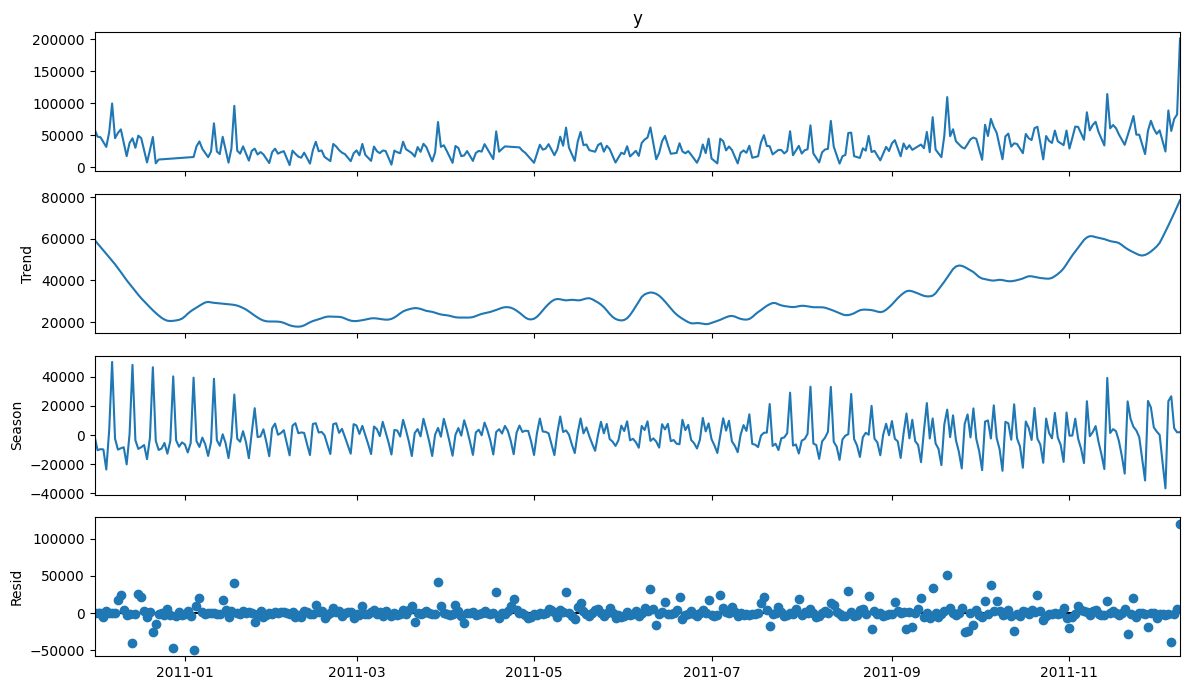

In [5]:
from statsmodels.tsa.seasonal import STL
s=df.set_index('date')['y'].asfreq(utils.FREQ).interpolate()
res=STL(s,period=utils.SEASONAL_PERIOD,robust=True).fit()
fig=res.plot(); fig.set_size_inches(12,7); plt.tight_layout(); plt.show()

## 5. Seasonal profile (by dayofweek)

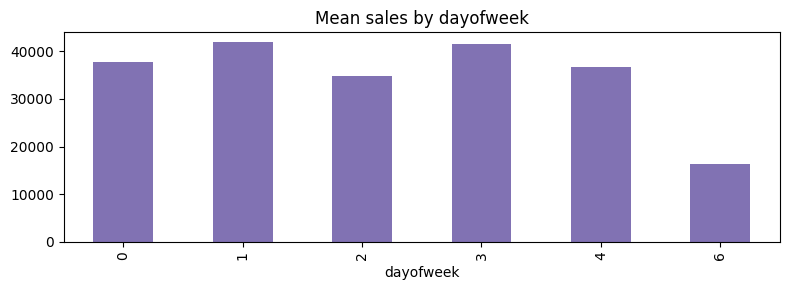

In [6]:
prof=df.assign(dayofweek=df['date'].dt.dayofweek).groupby('dayofweek')['y'].mean()
fig,ax=plt.subplots(figsize=(8,3)); prof.plot(kind='bar',ax=ax,color='#8172b3'); ax.set_title('Mean sales by dayofweek'); plt.tight_layout(); plt.show()

## 6. Autocorrelation (ACF)

How strongly each value correlates with its past — the spikes show which **lags** are informative features.

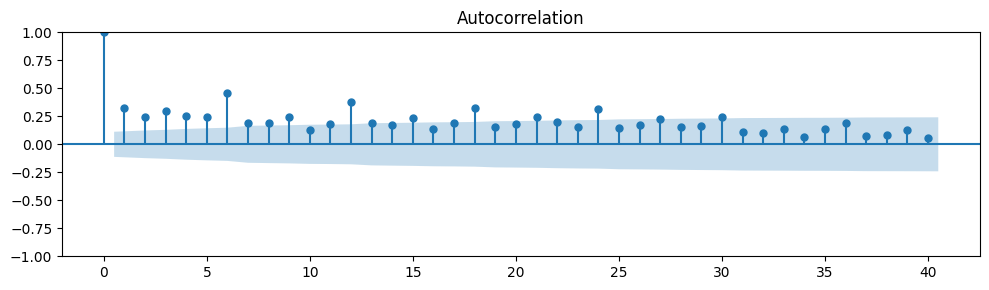

In [7]:
from statsmodels.graphics.tsaplots import plot_acf
fig,ax=plt.subplots(figsize=(10,3))
plot_acf(df['y'].dropna(),lags=min(40,len(df)//2-1),ax=ax); plt.tight_layout(); plt.show()

## 7. Summary

- The series shows weekly seasonality and a pre-Christmas ramp.
- Strong autocorrelation at short lags and at the weekly period justifies **lag + rolling + calendar features** (built in notebook 02).
- Notebook 03 forecasts with a chronological split and benchmarks ML models against naive baselines.